### Strategy Overview

This notebook implements a backtest for a **Long Strangle strategy** using monthly options data. We define trade entry and exit logic, track each round trip. This helps evaluate the risk and return characteristics of the strategy.


## Setup and Imports

We begin by importing the required libraries for data manipulation and visualization. 
Ensure you have the necessary packages like pandas, numpy, and matplotlib installed.


In [1]:
import pandas as pd
import numpy as np
# For plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-darkgrid')

## Load Option Data

We read the monthly SPX options data, ensure proper datetime formatting, and set the quote dates as the index for time series analysis.


In [2]:
options_monthly = pd.read_csv('monthly_spxdata_full.csv', index_col= 0)
options_monthly['expire_date'] = pd.to_datetime(options_monthly['expire_date'])
options_monthly['quote_date'] = pd.to_datetime(options_monthly['quote_date'])
options_monthly.index = options_monthly['quote_date']
options_monthly

,quote_date,underlying_last,symbol,expire_date,dte,c_delta,c_gamma,c_vega,c_theta,c_rho,...,p_delta,p_gamma,p_vega,p_theta,p_rho,p_iv,p_volume,strike_distance,strike_distance_pct,expiry_type
quote_date,,,,,,,,,,,,,,,,,,,,,
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00112,-0.01021,-0.00006,3.83803,3.0,3653.4,0.948,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00016,0.00000,0.00179,-0.00988,-0.00028,2.91754,1.0,3453.4,0.896,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00046,0.00000,0.00142,-0.00970,0.00000,2.39189,22.0,3253.4,0.844,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00020,0.00000,0.00174,-0.01039,-0.00045,2.02433,116.0,3053.4,0.792,Near Month
2023-01-04,2023-01-04,3853.39,SPX,2023-01-20,16.0,1.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00275,-0.00994,-0.00004,1.74278,1.0,2853.4,0.740,Near Month
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00056,0.00002,0.00422,-0.02546,0.00043,...,-0.93834,0.00009,0.23453,-0.50968,-0.02863,1.42827,8.0,594.9,0.125,Near Month
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00090,0.00005,0.00353,-0.02537,0.00027,...,-0.93669,0.00007,0.23876,-0.51061,-0.02881,1.54542,NaN,644.9,0.136,Near Month
2023-12-22,2023-12-22,4755.11,SPX,2023-12-22,0.0,0.00066,0.00000,0.00284,-0.02573,-0.00023,...,-0.92922,0.00006,0.25412,-0.51019,-0.02952,2.01438,NaN,844.9,0.178,Near Month


## Identify Key Trading Days

This section classifies each date in the dataset into categories such as first trading day, last trading day, day before last, or day before expiry. 
These labels help define trade entry and exit points.


In [3]:
# Get the first trading day for each year-month
first_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(lambda x: x.index.min())

# Get the last trading day for each year-month
last_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(lambda x: x.index.max())

# Get the second-to-last trading day for each year-month
def day_before_last(group):
    # Sort the dates by the index and get the second-to-last date
    sorted_dates = group.sort_index()
    if len(sorted_dates) > 1:
        return sorted_dates.index[-2]  # Correct access for second-to-last date
    else:
        return None

day_before_last_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(day_before_last)

# Get the day before expiry by checking the dates before the expiry
def day_before_expiry(group):
    # Ensure 'expire_date' is in datetime format
    expire_date = pd.to_datetime(group['expire_date'].iloc[0])  # Assuming 'expire_date' is the same for all rows in the group
    
    # Sort the dates by the index
    sorted_dates = group.sort_index()
    
    # Convert the sorted_dates index to datetime if it's not already
    sorted_dates = pd.to_datetime(sorted_dates.index)
    
    # Find the last available date before the expiry date
    day_before_expiry_date = sorted_dates[sorted_dates < expire_date].max()
    
    return day_before_expiry_date if pd.notna(day_before_expiry_date) else None

# Apply the function to get the 'day_before_expiry' for each group
day_before_expiry_trading_days = options_monthly.groupby(options_monthly.index.to_period('M')).apply(day_before_expiry)

# Now, we want to create the 'trading_day' column for the options_monthly DataFrame
def assign_trading_day(date, expire_date):
    if date in first_trading_days.values:
        return 'first'
    elif date in last_trading_days.values:
        return 'last'
    elif date in day_before_last_trading_days.values:
        return 'day_before_last'
    elif date in day_before_expiry_trading_days.values:
        return 'day_before_expiry'
    else:
        return 'regular'

# Apply the function to create the 'trading_day' column
options_monthly['trading_day'] = options_monthly.apply(
    lambda row: assign_trading_day(row.name, row['expire_date']), axis=1)

# To see the result
print(options_monthly[['trading_day']])

           trading_day
quote_date            
2023-01-04       first
2023-01-04       first
2023-01-04       first
2023-01-04       first
2023-01-04       first
...                ...
2023-12-22        last
2023-12-22        last
2023-12-22        last
2023-12-22        last
2023-12-22        last

[51527 rows x 1 columns]


### Prepare Underlying Data and Trading Day Labels

We start by extracting the underlying price data (`underlying_last`) and removing duplicates to get one value per date. Then, we map each date to its corresponding trading day label (e.g., "first", "day_before_expiry") using the `trading_day` information. This prepares a clean dataset to align strategy logic with key trading days.


In [4]:
# Drop duplicates in the 'underlying_last' column
underlying_data = options_monthly['underlying_last'].drop_duplicates()

# Create a DataFrame that has 'first_trading_day' for each unique 'quote_date'
trading_day_mapping = options_monthly.groupby(options_monthly.index)['trading_day'].first()

# Map the 'first_trading_day' to 'underlying_data' based on the index
underlying_data = underlying_data.to_frame()  # Convert 'underlying_data' to DataFrame to add a column
underlying_data['trading_day'] = underlying_data.index.map(trading_day_mapping)

# Check the result
print(underlying_data)


            underlying_last        trading_day
quote_date                                    
2023-01-04          3853.39              first
2023-01-05          3808.19            regular
2023-01-06          3894.20            regular
2023-01-09          3892.52            regular
2023-01-10          3919.78            regular
...                     ...                ...
2023-12-18          4740.46            regular
2023-12-19          4768.54            regular
2023-12-20          4698.15            regular
2023-12-21          4747.03  day_before_expiry
2023-12-22          4755.11               last

[175 rows x 2 columns]


### Validate Trading Day Labels

We ensure that for every expiry cycle, there is exactly one entry for the 'first', 'last', and 'day_before_expiry' trading days. This consistency check confirms that the strategy has a proper structure to identify entry and exit points across all expiry periods.


In [5]:
len(underlying_data[underlying_data.trading_day == 'first']) == len(
    underlying_data[underlying_data.trading_day == 'last']) == len(
        underlying_data[underlying_data.trading_day == 'day_before_expiry'])

True

## Long Strangle

### Select ATM and Adjacent Strikes for a Given Date

We begin by selecting option chain data for a specific analysis date (`2023-01-04`). The ATM (At-the-Money) strike is determined based on the strike with the minimum percentage distance from the underlying price. Once identified, we also extract the strikes immediately above and below the ATM to construct strategies like strangles or spreads that require multiple legs.


In [6]:
# Fetch data for analysis date
analysis_date = "2023-01-04"
 
# Select the options data that corresponds to the date
options_chain_test = options_monthly.loc[analysis_date]

atm_strike_price = options_chain_test[options_chain_test.strike_distance_pct == options_chain_test.strike_distance_pct.min()].strike.values[0]
print(atm_strike_price)

3855.0


In [7]:
# Find the index label of the minimum value
min_index = options_chain_test.strike_distance_pct.idxmin()

# Find the position of the minimum value (returns an integer index)
pos = options_chain_test.strike_distance_pct.argmin()

# Ensure `pos` is within bounds before selecting next/prev rows
prev_strike = options_chain_test.iloc[pos - 1].strike if pos > 0 else None
next_strike = options_chain_test.iloc[pos + 1].strike if pos < len(options_chain_test) - 1 else None

print("Next Strike:", next_strike)
print("Previous Strike:", prev_strike)


Next Strike: 3860.0
Previous Strike: 3850.0


We define the `get_premium` function to fetch the last traded premium for a given option. Based on whether the option is a Call (CE) or a Put (PE), it looks up the corresponding premium (`c_last` or `p_last`) from the daily options data using the strike price as the key. This function is essential for mark-to-market valuation and calculating PnL.

In [8]:
# Define the function to get the premium
def get_premium(options_strategy_input, options_data_input):
    
    if options_strategy_input['Option Type'] == 'CE':
        return options_data_input[options_data_input['strike'] == options_strategy_input['Strike Price']].c_last.values[0]
        
    if options_strategy_input['Option Type'] == 'PE':  # Corrected variable name
        return options_data_input[options_data_input['strike'] == options_strategy_input['Strike Price']].p_last.values[0]


In [9]:
# Create the long_strangle dataframe
long_strangle_test = pd.DataFrame()

# Set CE as call  
long_strangle_test['Option Type'] = ['CE', 'PE']

long_strangle_test['Strike Price'] = np.nan

# Set the position column to 1
long_strangle_test['position'] = 1


# Create 2 rows to store the OTM call and put options
long_strangle_test.loc[0] = ['CE', prev_strike, 1]
long_strangle_test.loc[1] = ['PE', next_strike, 1]

# Print the long_strangle_test dataframe
long_strangle_test

,Option Type,Strike Price,position
0,CE,3850.0,1
1,PE,3860.0,1


In [10]:
# Apply the function to the long_strangle dataframe and store the values in the premium column
long_strangle_test['premium'] = long_strangle_test.apply(
    lambda r: get_premium(r, options_chain_test), axis=1)

# Print the updated long_strangle dataframe
long_strangle_test

,Option Type,Strike Price,position,premium
0,CE,3850.0,1,67.24
1,PE,3860.0,1,65.30


### Define Function to Set Up a Long Strangle Strategy

This function sets up a **long strangle** strategy for a given `analysis_date` using the provided options chain. A long strangle involves buying one OTM Call and one OTM Put option:

- The OTM Call is selected as the strike **just above** the ATM strike.
- The OTM Put is selected as the strike **just below** the ATM strike.

The function constructs a DataFrame with two rows—one for each leg—and assigns the appropriate strike and premium using the `get_premium` function. The position is set to `+1` for a long position and `-1` if the strategy is reversed to a short strangle.


In [11]:
def setup_long_strangle(analysis_date, options_chain_input, direction='long'):
    long_strangle_data = pd.DataFrame()

    long_strangle_data['Option Type'] = ['CE', 'PE']
    atm_strike_price = options_chain_input[options_chain_input.strike_distance_pct == options_chain_input.strike_distance_pct.min()].strike.values[0]

    # Find the index label of the minimum value
    min_index = options_chain_input.strike_distance_pct.idxmin()

    # Find the position of the minimum value (returns an integer index)
    pos = options_chain_input.strike_distance_pct.argmin()

    # Ensure `pos` is within bounds before selecting next/prev rows
    prev_strike = options_chain_input.iloc[pos - 1].strike if pos > 0 else None
    next_strike = options_chain_input.iloc[pos + 1].strike if pos < len(options_chain_input) - 1 else None


    long_strangle_data['Strike Price'] = np.nan

    # Set the position column to 1
    long_strangle_data['position'] = 1


    # Create 2 rows to store the OTM call and put options
    long_strangle_data.loc[0] = ['CE', prev_strike, 1]
    long_strangle_data.loc[1] = ['PE', next_strike, 1]


    long_strangle_data['premium'] = long_strangle_data.apply(
        lambda r: get_premium(r, options_chain_input), axis=1)

    if direction == 'short':
        long_strangle_data['position'] *= -1

    long_strangle_data['premium'] = long_strangle_data.apply(
        lambda r: get_premium(r, options_chain_input), axis=1)

    return long_strangle_data

In [12]:
# Get the short long_strangle strategy dataframe
setup_long_strangle(analysis_date, options_chain_test, direction='long')

,Option Type,Strike Price,position,premium
0,CE,3850.0,1,67.24
1,PE,3860.0,1,65.30


### Backtest Execution Logic for Long Strangle Strategy

This section implements the core backtesting loop for executing a **long strangle strategy**. The process follows these steps:

- **Entry Condition**: A new position is initiated on the first trading day of each month. Using the `setup_long_strangle()` function, one out-of-the-money call and one out-of-the-money put are selected, and the net premium paid is recorded.
- **Tracking**: The strategy's daily mark-to-market (MTM) value is updated using live premiums fetched each day. All trades and premiums are saved for later analysis.
- **Exit Condition**: The position is closed on the day before expiry, and the realized profit or loss is calculated by comparing the exit premium with the entry premium.
- **Logging and PnL**: Each round trip (entry and exit) is logged with detailed trade information including the cumulative profit/loss across all trades.

This structure allows for clear tracking and performance evaluation of each strangle position during the monthly trading cycle.


In [13]:
# Create dataframes for round trips, storing trades, and mtm
round_trips_details = pd.DataFrame()
trades = pd.DataFrame()
mark_to_market = pd.DataFrame()

# Function for calculating mtm
def add_to_mtm(mark_to_market, option_strategy, trading_date):
    option_strategy['Date'] = trading_date
    mark_to_market = pd.concat([mark_to_market, option_strategy])
    return mark_to_market

# Initialise current position, number of trades and cumulative pnl to 0
current_position = 0
trade_num = 0
cum_pnl = 0

# Set exit flag to False
exit_flag = False

# Set start date for backtesting
start_date = underlying_data.index[0]

for i in underlying_data.loc[start_date:].index:

    if (current_position == 0) & (underlying_data.loc[i, 'trading_day'] == 'first'):

        # Setup long_strangle
        options_data_daily = options_monthly.loc[i]
        long_strangle_strategy = setup_long_strangle(i, options_data_daily, direction="long")

        # Populate the trades dataframe
        trades = long_strangle_strategy.copy()
        trades['entry_date'] = i
        trades.rename(columns={'premium': 'entry_price'}, inplace=True)            

        # Calculate net premium 
        net_premium = round((long_strangle_strategy.position * long_strangle_strategy.premium).sum(), 1)

        # Update current position to 1
        current_position = 1

        # Update mark_to_market dataframe
        mark_to_market = add_to_mtm(mark_to_market, long_strangle_strategy, i)

        # Increase number of trades by 1
        trade_num += 1  

        # Print formatted entry log
        print(f"\n━━━━ Trade No: {trade_num} ━━━━")
        print(f"  Entry:  ")
        print(f"    → Date: {i}  ")
        print(f"    → Premium Paid: {net_premium}  ")

    elif current_position == 1:

        # Update net premium
        options_data_daily = options_monthly.loc[i]
        long_strangle_strategy['premium'] = long_strangle_strategy.apply(lambda r: get_premium(r, options_data_daily), axis=1)        
        net_premium = (long_strangle_strategy.position * long_strangle_strategy.premium).sum()

        # Update mark_to_market dataframe
        mark_to_market = add_to_mtm(mark_to_market, long_strangle_strategy, i)

        # Exit at expiry
        if underlying_data.loc[i, 'trading_day'] == 'day_before_expiry':
            exit_type = 'Expiry'
            exit_flag = True    

        if exit_flag:

            # Update the trades dataframe
            trades['exit_date'] = i
            trades['exit_type'] = exit_type
            trades['exit_price'] = long_strangle_strategy.premium

            # Add the trade logs to round trip details
            round_trips_details = pd.concat([round_trips_details, trades])

            # Calculate net premium at exit
            net_premium = round((long_strangle_strategy.position * long_strangle_strategy.premium).sum(), 1)   

            # Calculate net premium on entry
            entry_net_premium = (trades.position * trades.entry_price).sum()       

            # Calculate pnl for the trade
            trade_pnl = round(net_premium - entry_net_premium, 1)

            # Calculate cumulative pnl
            cum_pnl += trade_pnl
            cum_pnl = round(cum_pnl, 2)

            # Print formatted exit log
            print(f"\n  Exit:  ")
            print(f"    → Type: {exit_type}  ")
            print(f"    → Date: {i}  ")
            print(f"    → Premium Received: {net_premium}  ")
            print(f"    → Profit/Loss: {trade_pnl}  ")
            print(f"    → Cumulative PnL: {cum_pnl}  ")

            # Update current position to 0
            current_position = 0    

            # Set exit flag to false
            exit_flag = False 



━━━━ Trade No: 1 ━━━━
  Entry:  
    → Date: 2023-01-04 00:00:00  
    → Premium Paid: 132.5  

  Exit:  
    → Type: Expiry  
    → Date: 2023-01-19 00:00:00  
    → Premium Received: 61.1  
    → Profit/Loss: -71.4  
    → Cumulative PnL: -71.4  

━━━━ Trade No: 2 ━━━━
  Entry:  
    → Date: 2023-02-01 00:00:00  
    → Premium Paid: 96.8  

  Exit:  
    → Type: Expiry  
    → Date: 2023-02-16 00:00:00  
    → Premium Received: 29.1  
    → Profit/Loss: -67.7  
    → Cumulative PnL: -139.1  

━━━━ Trade No: 3 ━━━━
  Entry:  
    → Date: 2023-03-01 00:00:00  
    → Premium Paid: 196.8  

  Exit:  
    → Type: Expiry  
    → Date: 2023-03-23 00:00:00  
    → Premium Received: 48.7  
    → Profit/Loss: -148.1  
    → Cumulative PnL: -287.2  

━━━━ Trade No: 4 ━━━━
  Entry:  
    → Date: 2023-04-03 00:00:00  
    → Premium Paid: 121.1  

  Exit:  
    → Type: Expiry  
    → Date: 2023-04-20 00:00:00  
    → Premium Received: 21.1  
    → Profit/Loss: -100.0  
    → Cumulative PnL: -387.

In [14]:
# Round trip details
round_trips_details

,Option Type,Strike Price,position,entry_price,entry_date,exit_date,exit_type,exit_price
0,CE,3850.0,1,67.24,2023-01-04,2023-01-19,Expiry,59.85
1,PE,3860.0,1,65.30,2023-01-04,2023-01-19,Expiry,1.21
0,CE,4115.0,1,40.41,2023-02-01,2023-02-16,Expiry,3.07
1,PE,4125.0,1,56.38,2023-02-01,2023-02-16,Expiry,26.06
0,CE,3945.0,1,116.17,2023-03-01,2023-03-23,Expiry,26.77
1,PE,3955.0,1,80.60,2023-03-01,2023-03-23,Expiry,21.95
0,CE,4120.0,1,61.62,2023-04-03,2023-04-20,Expiry,12.00
1,PE,4130.0,1,59.47,2023-04-03,2023-04-20,Expiry,9.10
0,CE,4160.0,1,66.60,2023-05-01,2023-05-18,Expiry,25.99
1,PE,4170.0,1,45.50,2023-05-01,2023-05-18,Expiry,0.95


In [15]:
# MTM details
mark_to_market[:20]

,Option Type,Strike Price,position,premium,Date
0,CE,3850.0,1,67.24,2023-01-04
1,PE,3860.0,1,65.30,2023-01-04
0,CE,3850.0,1,47.90,2023-01-05
1,PE,3860.0,1,89.27,2023-01-05
0,CE,3850.0,1,88.30,2023-01-06
1,PE,3860.0,1,42.07,2023-01-06
0,CE,3850.0,1,85.09,2023-01-09
1,PE,3860.0,1,38.10,2023-01-09
0,CE,3850.0,1,84.80,2023-01-10
1,PE,3860.0,1,35.30,2023-01-10


### Trade-Level PnL and Cost Adjustments

In this section, we process the round-trip data to compute **net PnL**, **turnover**, and **realistic returns** after including trading costs and slippages:

- **Lot Size**: A fixed lot size (e.g., 50) is assumed for all trades to scale up the PnL figures.
- **Trade-Wise PnL**: For each leg of the strangle, the profit or loss is computed as the product of position size and the difference between exit and entry prices.
- **Trade Aggregation**: We group trades by their entry date to consolidate them into round-trips and calculate:
  - Net PnL across both legs
  - Turnover (entry + exit premiums across both legs)
  - Net PnL after subtracting 1% costs on turnover (to simulate trading costs and slippage)

This step helps in analyzing the strategy's real-world profitability after accounting for execution friction.


In [16]:
# Assume lot size as 50
lot_size = 50

# Copy round trips data
round_trips = round_trips_details.copy()

# Calculate net premium PnL
round_trips['trade_wise_pnl'] = round_trips['position'] * (round_trips['exit_price'] - round_trips['entry_price'])

# Create an empty dataframe for storing trades
trades = pd.DataFrame()

# Groupby entry date
trades_group = round_trips.groupby('entry_date')

# Extract necessary columns and rename them properly
trades['entry_date'] = trades_group['entry_date'].first()
trades['exit_date'] = trades_group['exit_date'].first()
trades['exit_type'] = trades_group['exit_type'].first()

# Calculate PnL for the strategy per lot
trades['pnl'] = trades_group['trade_wise_pnl'].sum() * lot_size

# Calculate turnover for trades
trades['turnover'] = (trades_group['exit_price'].sum() + trades_group['entry_price'].sum()) * lot_size

# Calculate PnL after trading costs and slippages (assuming 1% cost)
trades['pnl_post_trading_costs_slippages'] = trades['pnl'] - trades['turnover'] * 0.01

# Reset index and remove redundant 'entry_date' index
trades.reset_index(drop=True, inplace=True)

# Display final trades DataFrame
trades


,entry_date,exit_date,exit_type,pnl,turnover,pnl_post_trading_costs_slippages
0,2023-01-04,2023-01-19,Expiry,-3574.0,9680.0,-3670.800
1,2023-02-01,2023-02-16,Expiry,-3383.0,6296.0,-3445.960
2,2023-03-01,2023-03-23,Expiry,-7402.5,12274.5,-7525.245
3,2023-04-03,2023-04-20,Expiry,-4999.5,7109.5,-5070.595
4,2023-05-01,2023-05-18,Expiry,-4258.0,6952.0,-4327.520
5,2023-06-01,2023-06-22,Expiry,3343.0,14737.0,3195.630
6,2023-07-03,2023-07-20,Expiry,1082.5,10167.5,980.825
7,2023-08-01,2023-08-17,Expiry,3972.0,12872.0,3843.280
8,2023-09-01,2023-09-21,Expiry,3948.0,14084.0,3807.160
9,2023-10-02,2023-10-19,Expiry,-4784.0,7846.0,-4862.460


### Visualizing Entry and Exit Points

To gain a clearer understanding of the trading activity, this section plots:

- **Underlying Price (blue)** on the primary y-axis.
- **Position Status (green)** on the secondary y-axis:
  - `1` when a long strangle position is active
  - `0` when there is no position

We mark entry dates with a position switch to `1` and exit dates with a switch to `0`, and forward-fill the position state to reflect active trades between these dates. This plot helps validate whether trades are being placed and exited in line with the intended strategy logic.


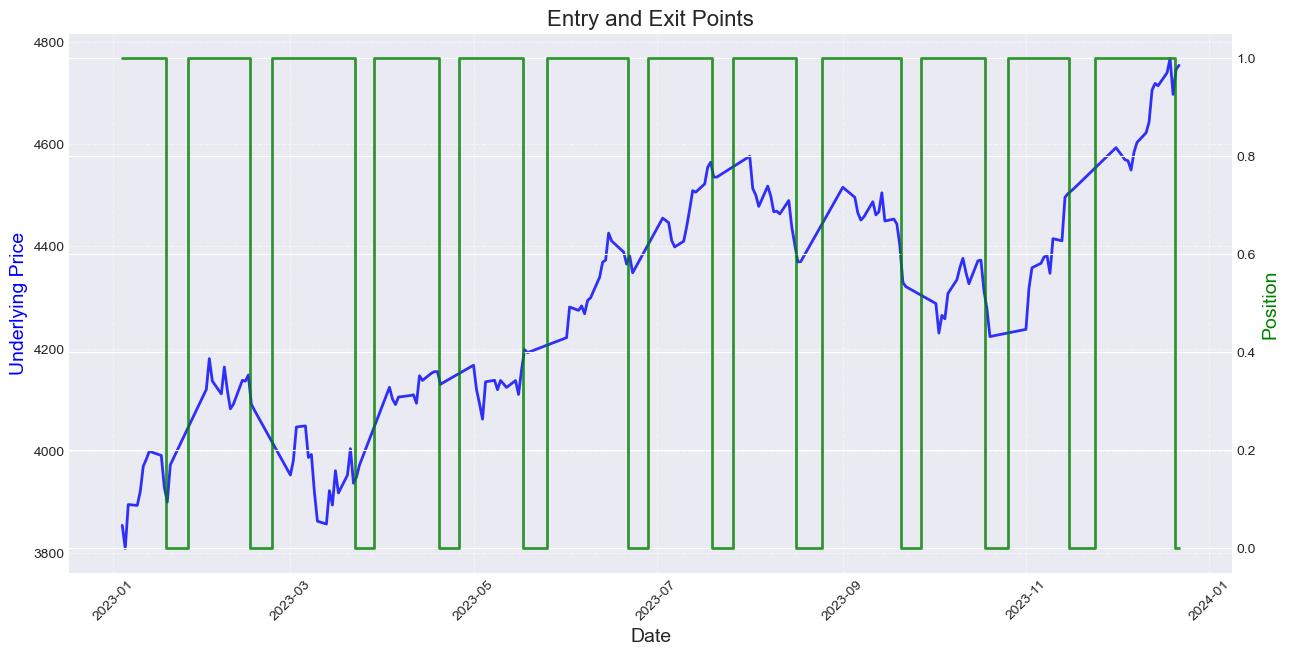

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Copy the data
underlying_daily_data = underlying_data.copy()

# Track entry and exit positions
underlying_daily_data['position'] = np.nan
underlying_daily_data.loc[underlying_daily_data.index.isin(trades['entry_date']), 'position'] = 1
underlying_daily_data.loc[underlying_daily_data.index.isin(trades['exit_date']), 'position'] = 0

# Forward-fill missing values in the position column
underlying_daily_data['position'].fillna(method='ffill', inplace=True)

# Select data from the first trade entry date
data_for_plot = underlying_daily_data.loc[trades.entry_date.iloc[0]:]

# Create figure
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot underlying price
ax1.plot(data_for_plot.index, data_for_plot['underlying_last'], 
         color='blue', linewidth=2, alpha=0.8, label="Underlying Price")

# Set primary y-axis label
ax1.set_ylabel('Underlying Price', fontsize=14, color='blue')
ax1.set_xlabel('Date', fontsize=14)

# Create secondary y-axis for position tracking
ax2 = ax1.twinx()
ax2.step(data_for_plot.index, data_for_plot['position'], 
         where='mid', color='green', linewidth=2, alpha=0.8, linestyle='-', label="Position")

# Set secondary y-axis label
ax2.set_ylabel('Position', fontsize=14, color='green')

# Formatting
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_title('Entry and Exit Points', fontsize=16)
ax1.tick_params(axis='x', labelrotation=45)



## Conclusion

In this notebook, we implemented and backtested a basic long strangle strategy on SPX options.  
While the core logic of trade entry and exit was covered, performance evaluation and risk management were not included.

As a next step, you are encouraged to:
- Calculate performance metrics like CAGR, volatility, and drawdown.
- Add entry filters based on implied or historical volatility.
- Implement systematic risk management using stoploss or take profit levels.

These enhancements will help you evaluate and refine the strategy for real-world use.
